# Model Training & Comparison — Fraud Detection Capstone
**Goal:** Train and compare 5 models. Track all experiments with MLflow.  
**Models:** Logistic Regression, Random Forest, LightGBM, XGBoost, Isolation Forest  
**Primary metrics:** PR-AUC, F1 (fraud class), ROC-AUC

In [2]:
import os
os.chdir('..')
print(os.getcwd())

/Users/cds.chintan/IIT PG DS & AI/Sem 3/AIML Project/fraud-detection-capstone


## 1. Setup

In [3]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import time
warnings.filterwarnings('ignore')

# ML
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score,
    average_precision_score, confusion_matrix,
    f1_score, precision_score, recall_score,
    PrecisionRecallDisplay, RocCurveDisplay
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import lightgbm as lgb

# MLflow
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
TARGET       = 'is_fraud'

print('All imports successful.')

All imports successful.


## 2. Load Processed Data

In [4]:
train = pd.read_csv('data/processed/train_preprocessed.csv')
test  = pd.read_csv('data/processed/test_preprocessed.csv')

# Drop any remaining datetime or string columns
train = train.select_dtypes(include=[np.number])
test  = test.select_dtypes(include=[np.number])

X      = train.drop(columns=[TARGET])
y      = train[TARGET]
X_test = test.drop(columns=[TARGET])
y_test = test[TARGET]


# Train / validation split — stratified to preserve fraud ratio
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train  : {X_train.shape} | Fraud rate: {y_train.mean():.4%}')
print(f'Val    : {X_val.shape}   | Fraud rate: {y_val.mean():.4%}')
print(f'Test   : {X_test.shape}  | Fraud rate: {y_test.mean():.4%}')

Train  : (1037340, 16) | Fraud rate: 0.5789%
Val    : (259335, 16)   | Fraud rate: 0.5788%
Test   : (555719, 16)  | Fraud rate: 0.3860%


## 3. Scaling & SMOTE
Scale features for Logistic Regression. Apply SMOTE on training set only — never on val or test.

In [5]:
# Scale — fit on train, transform train/val/test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# SMOTE — only on training set
print('Applying SMOTE to training set...')
sm = SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.1)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)

print(f'Before SMOTE — Fraud: {y_train.sum():,} | Legit: {(y_train==0).sum():,}')
print(f'After  SMOTE — Fraud: {y_train_sm.sum():,} | Legit: {(y_train_sm==0).sum():,}')

# Save scaler for later use in prediction + agent layer
os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/scaler.pkl')
print('Scaler saved to models/scaler.pkl')

Applying SMOTE to training set...
Before SMOTE — Fraud: 6,005 | Legit: 1,031,335
After  SMOTE — Fraud: 103,133 | Legit: 1,031,335
Scaler saved to models/scaler.pkl


## 4. MLflow Setup

In [6]:
EXPERIMENT_NAME = 'fraud-detection-capstone'
mlflow.set_tracking_uri('mlruns')  # local folder
mlflow.set_experiment(EXPERIMENT_NAME)

print(f'MLflow experiment set: {EXPERIMENT_NAME}')
print(f'Tracking URI: mlruns/')
print('Run: mlflow ui  in terminal to view results')

MLflow experiment set: fraud-detection-capstone
Tracking URI: mlruns/
Run: mlflow ui  in terminal to view results


## 5. Helper — Evaluate & Log to MLflow

In [7]:
results = {}  # store all model results for final comparison

def evaluate_and_log(model_name, model, X_val_input, y_val_input,
                     params: dict, is_anomaly=False):
    """
    Evaluate model on validation set and log everything to MLflow.
    is_anomaly=True for Isolation Forest (different prediction logic).
    """
    with mlflow.start_run(run_name=model_name):

        # --- Predict ---
        if is_anomaly:
            # Isolation Forest: -1=anomaly(fraud), 1=normal → convert to 0/1
            raw_preds = model.predict(X_val_input)
            y_pred    = np.where(raw_preds == -1, 1, 0)
            y_prob    = -model.score_samples(X_val_input)  # higher = more anomalous
            y_prob    = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())  # normalise 0-1
        else:
            y_pred = model.predict(X_val_input)
            y_prob = model.predict_proba(X_val_input)[:, 1]

        # --- Metrics ---
        roc_auc  = roc_auc_score(y_val_input, y_prob)
        pr_auc   = average_precision_score(y_val_input, y_prob)
        f1       = f1_score(y_val_input, y_pred)
        precision = precision_score(y_val_input, y_pred, zero_division=0)
        recall   = recall_score(y_val_input, y_pred)

        # --- Log to MLflow ---
        mlflow.log_params(params)
        mlflow.log_metrics({
            'roc_auc'  : round(roc_auc, 4),
            'pr_auc'   : round(pr_auc,  4),
            'f1_fraud' : round(f1,      4),
            'precision': round(precision, 4),
            'recall'   : round(recall,  4),
        })

        # Store for comparison
        results[model_name] = {
            'roc_auc'  : roc_auc,
            'pr_auc'   : pr_auc,
            'f1_fraud' : f1,
            'precision': precision,
            'recall'   : recall,
            'y_prob'   : y_prob,
            'y_pred'   : y_pred,
        }

        print(f'\n--- {model_name} ---')
        print(f'ROC-AUC : {roc_auc:.4f}')
        print(f'PR-AUC  : {pr_auc:.4f}  ← primary metric')
        print(f'F1      : {f1:.4f}')
        print(f'Prec    : {precision:.4f}  |  Recall: {recall:.4f}')

    return results[model_name]

## 6. Model 1 — Logistic Regression (Baseline)

In [8]:
print('Training Logistic Regression...')
t0 = time.time()

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=500,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lr.fit(X_train_sm, y_train_sm)
print(f'Training time: {time.time()-t0:.1f}s')

evaluate_and_log(
    'Logistic Regression', lr, X_val_scaled, y_val,
    params={'model': 'LogisticRegression', 'class_weight': 'balanced', 'max_iter': 500}
)

Training Logistic Regression...
Training time: 3.2s

--- Logistic Regression ---
ROC-AUC : 0.9435
PR-AUC  : 0.2904  ← primary metric
F1      : 0.0668
Prec    : 0.0347  |  Recall: 0.8508


{'roc_auc': 0.9435085014105905,
 'pr_auc': 0.2904460740907059,
 'f1_fraud': 0.06676775070584545,
 'precision': 0.03474735381350167,
 'recall': 0.8507661558960693,
 'y_prob': array([0.3372773 , 0.05576537, 0.29595962, ..., 0.06839431, 0.64008033,
        0.04296987]),
 'y_pred': array([0, 0, 0, ..., 0, 1, 0])}

## 7. Model 2 — Random Forest

In [9]:
print('Training Random Forest...')
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)
print(f'Training time: {time.time()-t0:.1f}s')

evaluate_and_log(
    'Random Forest', rf, X_val_scaled, y_val,
    params={'model': 'RandomForest', 'n_estimators': 200, 'max_depth': 12}
)

Training Random Forest...
Training time: 86.4s

--- Random Forest ---
ROC-AUC : 0.9923
PR-AUC  : 0.8452  ← primary metric
F1      : 0.5284
Prec    : 0.3729  |  Recall: 0.9067


{'roc_auc': 0.9923141986986271,
 'pr_auc': 0.845150677169226,
 'f1_fraud': 0.5284410794020579,
 'precision': 0.3728767123287671,
 'recall': 0.9067288474350433,
 'y_prob': array([0.0973062 , 0.01011023, 0.03509147, ..., 0.04545011, 0.08974608,
        0.01135348]),
 'y_pred': array([0, 0, 0, ..., 0, 0, 0])}

## 8. Model 3 — LightGBM

In [10]:
print('Training LightGBM...')
t0 = time.time()

lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
lgbm.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_val_scaled, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)
print(f'Training time: {time.time()-t0:.1f}s')

evaluate_and_log(
    'LightGBM', lgbm, X_val_scaled, y_val,
    params={'model': 'LightGBM', 'n_estimators': 500,
            'max_depth': 8, 'learning_rate': 0.05}
)

Training LightGBM...
Training time: 1.6s

--- LightGBM ---
ROC-AUC : 0.9769
PR-AUC  : 0.2427  ← primary metric
F1      : 0.0000
Prec    : 0.0000  |  Recall: 0.0000


{'roc_auc': 0.9769291015718777,
 'pr_auc': 0.24267926027780398,
 'f1_fraud': 0.0,
 'precision': 0.0,
 'recall': 0.0,
 'y_prob': array([0.14651204, 0.09035174, 0.10127871, ..., 0.10127871, 0.12958857,
        0.09035174]),
 'y_pred': array([0, 0, 0, ..., 0, 0, 0])}

## 9. Model 4 — XGBoost (Primary Model)

In [11]:
print('Training XGBoost...')
t0 = time.time()

scale_pos = (y_train==0).sum() / (y_train==1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)
print(f'Training time: {time.time()-t0:.1f}s')

evaluate_and_log(
    'XGBoost', xgb, X_val_scaled, y_val,
    params={'model': 'XGBoost', 'n_estimators': 500,
            'max_depth': 6, 'learning_rate': 0.05,
            'scale_pos_weight': round(scale_pos, 2)}
)

# Save best model
joblib.dump(xgb, 'models/xgboost_model.pkl')
print('XGBoost model saved to models/xgboost_model.pkl')

Training XGBoost...
Training time: 28.5s

--- XGBoost ---
ROC-AUC : 0.9981
PR-AUC  : 0.9251  ← primary metric
F1      : 0.4173
Prec    : 0.2658  |  Recall: 0.9707
XGBoost model saved to models/xgboost_model.pkl


## 10. Model 5 — Isolation Forest (Anomaly Detection)
Note: Evaluated separately — unsupervised model, different framing.

In [12]:
print('Training Isolation Forest...')
t0 = time.time()

# Isolation Forest trains on ALL data (unsupervised — ignores labels)
iso = IsolationForest(
    n_estimators=200,
    contamination=0.006,  # approx fraud rate
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso.fit(X_train_scaled)  # no labels — unsupervised
print(f'Training time: {time.time()-t0:.1f}s')

evaluate_and_log(
    'Isolation Forest', iso, X_val_scaled, y_val,
    params={'model': 'IsolationForest', 'n_estimators': 200,
            'contamination': 0.006},
    is_anomaly=True
)

Training Isolation Forest...
Training time: 8.6s

--- Isolation Forest ---
ROC-AUC : 0.8883
PR-AUC  : 0.0694  ← primary metric
F1      : 0.1255
Prec    : 0.1272  |  Recall: 0.1239


{'roc_auc': 0.8882722635731877,
 'pr_auc': 0.06939031692436973,
 'f1_fraud': 0.12554843064461693,
 'precision': 0.12722298221614228,
 'recall': 0.12391738840772819,
 'y_prob': array([0.41662207, 0.21148437, 0.23146084, ..., 0.23862798, 0.29740303,
        0.15727081]),
 'y_pred': array([0, 0, 0, ..., 0, 0, 0])}

## 11. Model Comparison

In [13]:
# Build comparison dataframe
comparison = pd.DataFrame({
    model: {
        'PR-AUC'   : round(v['pr_auc'],    4),
        'ROC-AUC'  : round(v['roc_auc'],   4),
        'F1-Fraud' : round(v['f1_fraud'],  4),
        'Precision': round(v['precision'], 4),
        'Recall'   : round(v['recall'],    4),
    }
    for model, v in results.items()
}).T.sort_values('PR-AUC', ascending=False)

print('=' * 65)
print('              MODEL COMPARISON (sorted by PR-AUC)')
print('=' * 65)
print(comparison.to_string())
print('=' * 65)
print(f'\nWinner: {comparison.index[0]} — PR-AUC: {comparison["PR-AUC"].iloc[0]}')
print('Note: Isolation Forest excluded from ranking — unsupervised model.')

              MODEL COMPARISON (sorted by PR-AUC)
                     PR-AUC  ROC-AUC  F1-Fraud  Precision  Recall
XGBoost              0.9251   0.9981    0.4173     0.2658  0.9707
Random Forest        0.8452   0.9923    0.5284     0.3729  0.9067
Logistic Regression  0.2904   0.9435    0.0668     0.0347  0.8508
LightGBM             0.2427   0.9769    0.0000     0.0000  0.0000
Isolation Forest     0.0694   0.8883    0.1255     0.1272  0.1239

Winner: XGBoost — PR-AUC: 0.9251
Note: Isolation Forest excluded from ranking — unsupervised model.


## 12. Visualise — PR Curves & ROC Curves

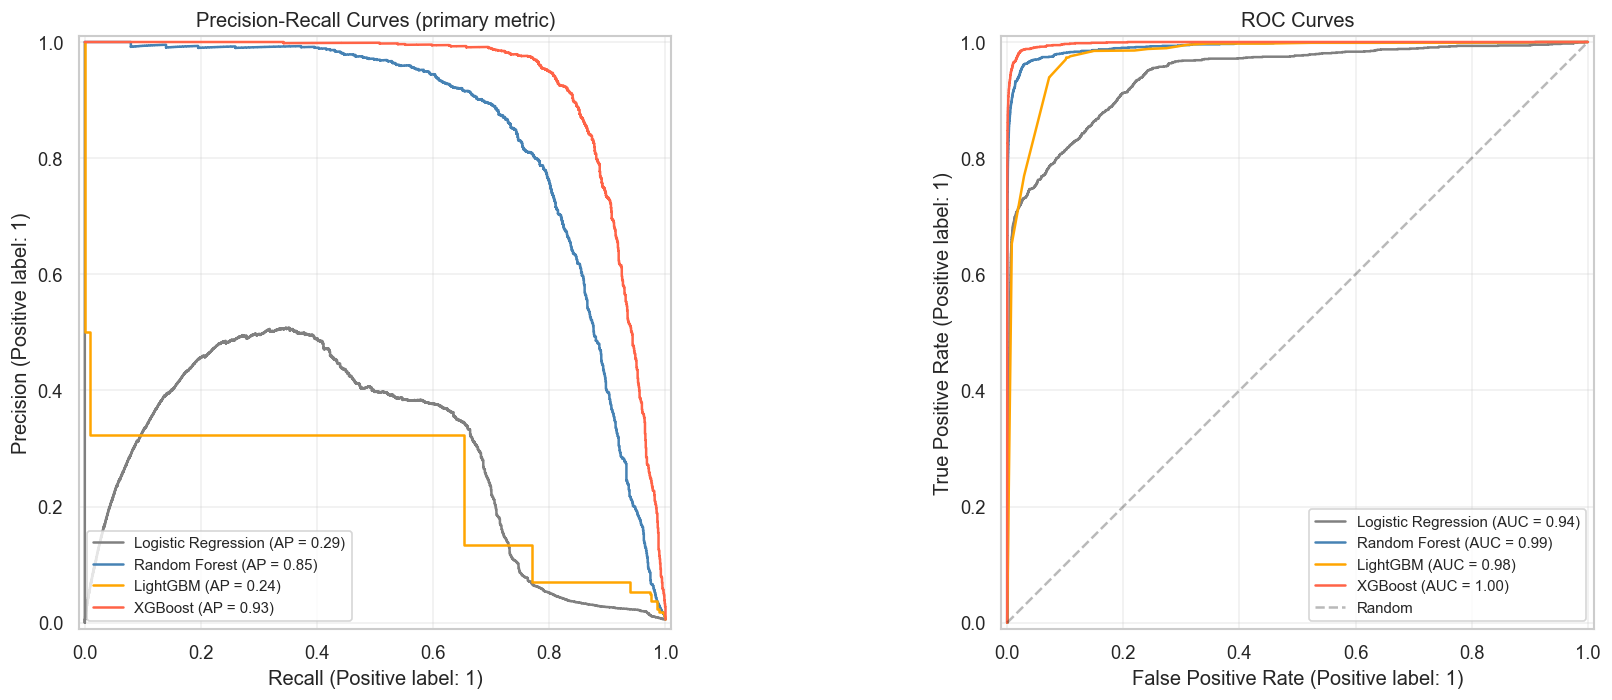

In [14]:
supervised_models = {
    'Logistic Regression': lr,
    'Random Forest'      : rf,
    'LightGBM'           : lgbm,
    'XGBoost'            : xgb,
}
colors = ['gray', 'steelblue', 'orange', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for (name, model), color in zip(supervised_models.items(), colors):
    PrecisionRecallDisplay.from_estimator(
        model, X_val_scaled, y_val,
        name=name, ax=axes[0], color=color
    )
    RocCurveDisplay.from_estimator(
        model, X_val_scaled, y_val,
        name=name, ax=axes[1], color=color
    )

axes[0].set_title('Precision-Recall Curves (primary metric)')
axes[1].set_title('ROC Curves')
axes[1].plot([0,1],[0,1],'k--', alpha=0.3, label='Random')

for ax in axes:
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reports/figures/model_comparison_curves.png', bbox_inches='tight')
plt.show()

## 13. Feature Importance — XGBoost

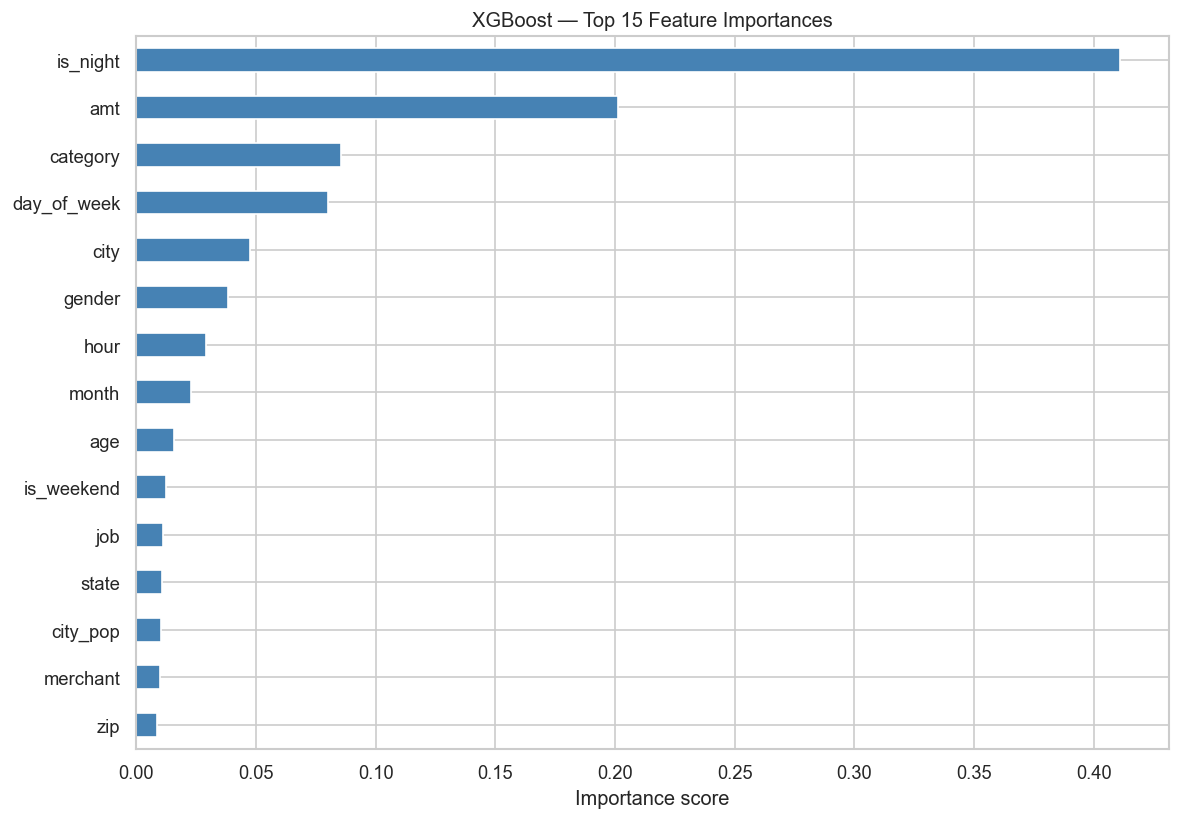

Top 5 features:
is_night       0.410789
amt            0.201069
category       0.085684
day_of_week    0.080066
city           0.047382


In [15]:
feat_imp = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
feat_imp.tail(15).plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('XGBoost — Top 15 Feature Importances')
plt.xlabel('Importance score')
plt.tight_layout()
plt.savefig('reports/figures/feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 features:')
print(feat_imp.tail(5).sort_values(ascending=False).to_string())

## 14. Confusion Matrix — XGBoost on Test Set

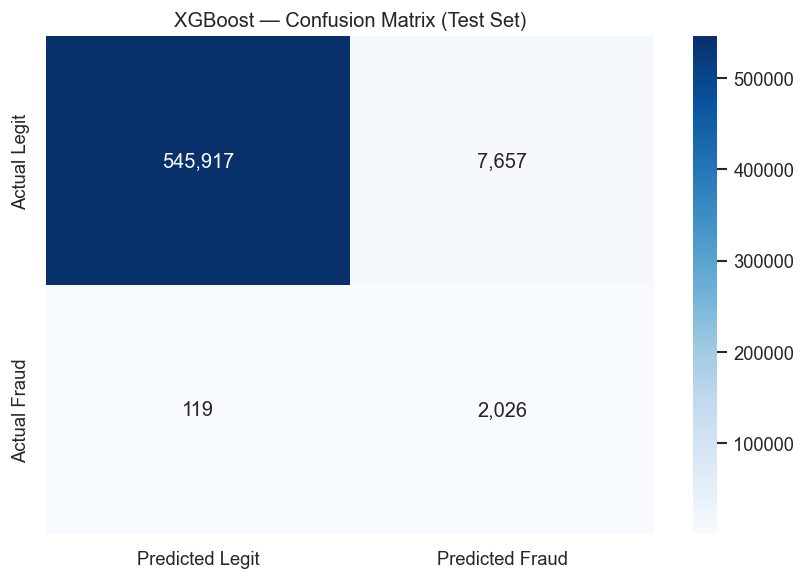


Test Set Performance — XGBoost
              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99    553574
       Fraud       0.21      0.94      0.34      2145

    accuracy                           0.99    555719
   macro avg       0.60      0.97      0.67    555719
weighted avg       1.00      0.99      0.99    555719

Test PR-AUC  : 0.8633
Test ROC-AUC : 0.9960


In [16]:
y_test_pred = xgb.predict(X_test_scaled)
y_test_prob = xgb.predict_proba(X_test_scaled)[:, 1]

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            xticklabels=['Predicted Legit','Predicted Fraud'],
            yticklabels=['Actual Legit','Actual Fraud'])
plt.title('XGBoost — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig('reports/figures/confusion_matrix.png', bbox_inches='tight')
plt.show()

print('\nTest Set Performance — XGBoost')
print(classification_report(y_test, y_test_pred, target_names=['Legit','Fraud']))
print(f'Test PR-AUC  : {average_precision_score(y_test, y_test_prob):.4f}')
print(f'Test ROC-AUC : {roc_auc_score(y_test, y_test_prob):.4f}')

## 15. Model Registry — register best model to MLflow Model Registry

In [ ]:
# Model Registry — register best model to MLflow Model Registry
import mlflow.xgboost

with mlflow.start_run(run_name="XGBoost_registered"):
    # Log params
    mlflow.log_params({
        'model'        : 'XGBoost',
        'n_estimators' : 500,
        'max_depth'    : 6,
        'learning_rate': 0.05,
        'smote'        : True,
    })
    # Log metrics
    mlflow.log_metrics({
        'pr_auc'   : results['XGBoost']['pr_auc'],
        'roc_auc'  : results['XGBoost']['roc_auc'],
        'f1_fraud' : results['XGBoost']['f1_fraud'],
        'precision': results['XGBoost']['precision'],
        'recall'   : results['XGBoost']['recall'],
    })
    # Log and register model
    mlflow.xgboost.log_model(
        xgb_model             = xgb,
        name         = "xgboost_fraud_model",
        registered_model_name = "fraud-detection-xgboost"
    )
    print("Model registered to MLflow Model Registry.")
    print("Go to MLflow UI → Models tab to see it.")

2026/05/06 23:00:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Model registered to MLflow Model Registry.
Go to MLflow UI → Models tab to see it.


Successfully registered model 'fraud-detection-xgboost'.
Created version '1' of model 'fraud-detection-xgboost'.


Exception ignored in: <function ResourceTracker.__del__ at 0x118915120>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103bd5120>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/m

## 16. View Results in MLflow UI

In [19]:
print('All 5 models logged to MLflow.')
print()
print('To view the MLflow UI:')
print('  1. Open a new terminal in VS Code')
print('  2. Activate venv: source venv/bin/activate')
print('  3. Run: mlflow ui')
print('  4. Open browser: http://127.0.0.1:5000')
print()
print('You will see all 5 runs side by side with metrics, params, and artifacts.')

All 5 models logged to MLflow.

To view the MLflow UI:
  1. Open a new terminal in VS Code
  2. Activate venv: source venv/bin/activate
  3. Run: mlflow ui
  4. Open browser: http://127.0.0.1:5000

You will see all 5 runs side by side with metrics, params, and artifacts.
